# Task
The task is to build and evaluate a RandomForestClassifier model for customer churn prediction using the 'Churn Modelling Dataset' CSV file, including data preprocessing, feature engineering, model training, evaluation, and an analysis of feature importances.

## Import Libraries



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset




In [4]:
df = pd.read_csv('Churn_Modelling.csv')
print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)
print("First 5 rows of the dataset:\n", df.head())

Dataset loaded successfully.
Shape of the dataset: (10000, 14)
First 5 rows of the dataset:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1      

## Data Cleaning


In [5]:
print('Missing values in each column:\n', df.isnull().sum())
if df.isnull().sum().sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found. Further action might be required.")

Missing values in each column:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
No missing values found in the dataset.


In [6]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
print("Dropped 'RowNumber', 'CustomerId', and 'Surname' columns.")
print("First 5 rows of the dataset after dropping columns:\n", df.head())

Dropped 'RowNumber', 'CustomerId', and 'Surname' columns.
First 5 rows of the dataset after dropping columns:
    CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [7]:
print("Data types of all columns:")
df.info()

Data types of all columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


## Encode Categorical Variables



In [8]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
print("Label Encoding applied to 'Gender' column.")
print("First 5 rows of the dataset after encoding 'Gender':\n", df.head())

Label Encoding applied to 'Gender' column.
First 5 rows of the dataset after encoding 'Gender':
    CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France       0   42       2       0.00              1   
1          608     Spain       0   41       1   83807.86              1   
2          502    France       0   42       8  159660.80              3   
3          699    France       0   39       1       0.00              2   
4          850     Spain       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [9]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)
print("One-Hot Encoding applied to 'Geography' column.")
print("First 5 rows of the dataset after encoding 'Geography':\n", df.head())

One-Hot Encoding applied to 'Geography' column.
First 5 rows of the dataset after encoding 'Geography':
    CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1                  0                0  
1               1        112542.58       0                  0                1  
2               0        113931.57       1                  0                0  
3               0         93826.63       0                  0                0  
4               1         79084.1

## Feature and Target Split

Separate the preprocessed dataset into features (X) and the target variable (y), where 'Exited' represents customer churn.


In [10]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print("First 5 rows of features (X):")
print(X.head())
print("\nFirst 5 rows of target (y):")
print(y.head())

First 5 rows of features (X):
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  
0               1        101348.88                  0                0  
1               1        112542.58                  0                1  
2               0        113931.57                  0                0  
3               0         93826.63                  0                0  
4               1         79084.10                  0                1  

First 5 rows of target (y):
0    1
1    0
2    1
3    0
4    0
Name: Exite

## Train-Test Split

Split the feature and target datasets into training and testing sets using an 80/20 ratio to prepare for model training and evaluation.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 11)
Shape of X_test: (2000, 11)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


## Train Classification Model



In [12]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


## Model Evaluation


In [13]:
y_pred = rf_model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


**Reasoning**:
Now that predictions have been made, I will calculate the accuracy score, generate the confusion matrix, and print the classification report to evaluate the model's performance on the test set, as per the remaining instructions.



In [14]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy Score: 0.8660

Confusion Matrix:
 [[1552   55]
 [ 213  180]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



## Feature Importance Analysis



In [15]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 Feature Importances:\n", feature_importances.head(10))

Top 10 Feature Importances:
 Age                  0.239783
EstimatedSalary      0.146638
CreditScore          0.144214
Balance              0.138613
NumOfProducts        0.130255
Tenure               0.082427
IsActiveMember       0.041110
Geography_Germany    0.025711
Gender               0.019258
HasCrCard            0.018722
dtype: float64


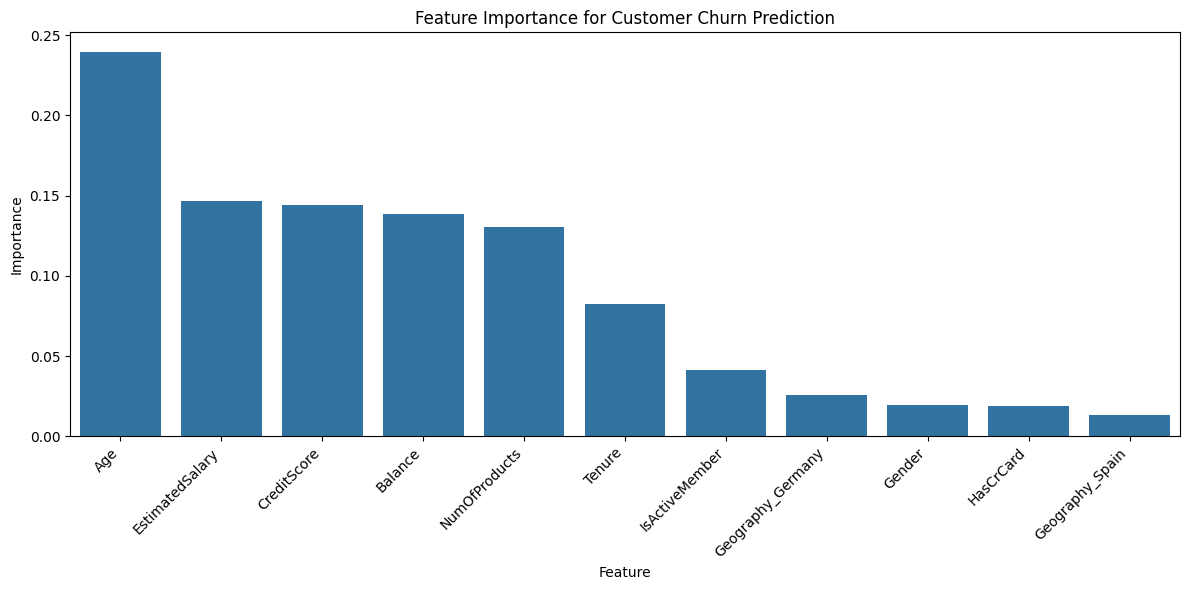

Feature importance plot displayed.


In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances.index, y=feature_importances.values)
plt.title('Feature Importance for Customer Churn Prediction')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Feature importance plot displayed.")

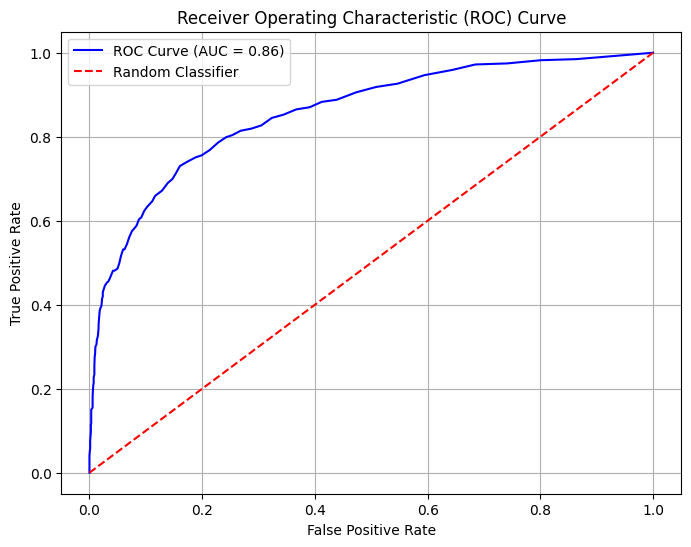

AUC Score: 0.8569


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score: {auc:.4f}")